In [1]:
from py_files.setup import *
setup_notebook()

# Investment composition

Decomposes Danish gross investment (1966–2024) into four capital types using direct final-demand weights from the NAIO1F input-output tables. The shift from tangible (structures, equipment) to intangible (IPP, organisational) capital provides empirical motivation for the model's two-sector structure.

For each industry $i$, let $I_i$ denote output sold directly to gross fixed capital formation and $Z_i$ intermediate sales. Each sub-industry is assigned a capital type $\tau(i) \in \{\text{structures},\,\text{equipment},\,\text{IPP},\,\text{organisational}\}$, with total investment attributable to type $\tau$

$$
    \zeta_\tau = \begin{cases}
        \displaystyle\sum_{i=1}^{69} I_i\,\mathbb{1}[\tau(i)=\tau]
        & \tau \neq \text{organisational} \\[10pt]
        0.6\cdot\displaystyle\sum_{i \in \mathcal{O}} Z_i
        & \tau = \text{organisational}
    \end{cases}
$$

where $\mathcal{O}$ is the set of organisational-capital industries. Organisational capital is imputed as 60% of intermediate sales from $\mathcal{O}$, following Corrado et al. (2009). Series are normalised by GDP.

In [2]:
investment_timeseries = il.load_or_compute_timeseries(years=range(1966, 2025))

Loading timeseries from 0_intermediate/timeseries_1966_2024.parquet …


*`1. stacked area: tangible vs intangible`*

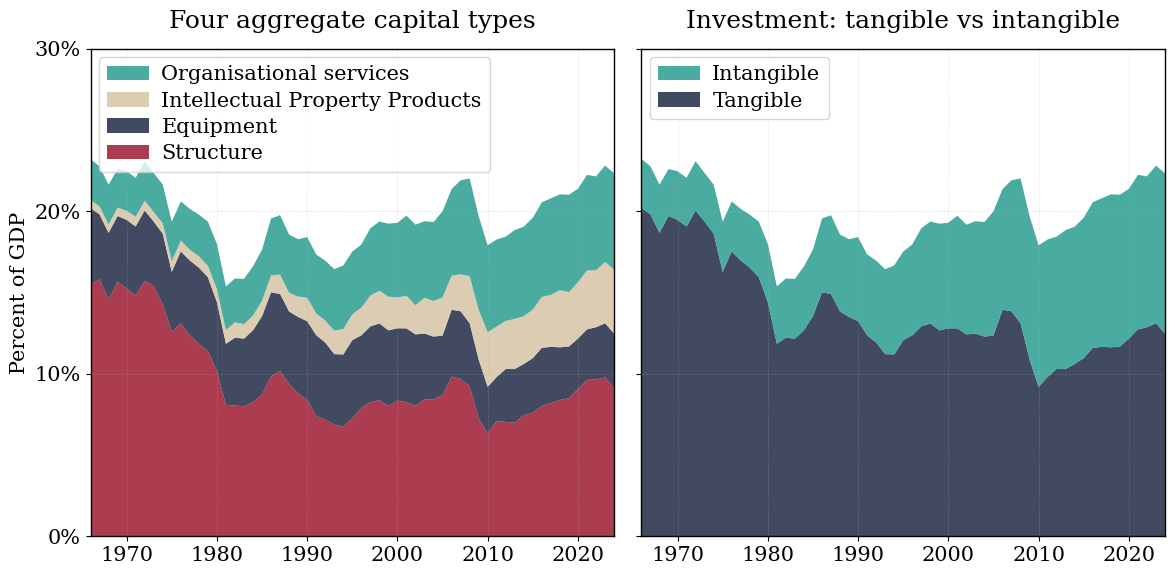

In [3]:
il.plot_investment_composition(
    investment_timeseries, 
    as_pct_gdp=True
)

In [14]:
# # Check the results
# print("\nInvestment as % of GDP:")
# print(investment_timeseries[
#     ['structures', 'equipment', 'intellectual_property', 'organizational']]
# )

*`2. appendix table`*

Aggregates sub-industries to the 36-parent level. Columns report direct final-demand shares $(C, I^{\text{tan}}, I^{\text{intan}}, X)$ as fractions of total use, Leontief-consolidated labour shares $\ell_i^{\text{cons}}$, and industry size relative to GDP.

In [15]:
# result = il.compute_direct_for_year(2024)
result = il.load_or_compute_year(2024)

use_shares = result['use_shares']

gdp = il.fetch_gdp_data([2017]).iloc[0]

table = (use_shares[['C_share', 'I_share', 'X_share']]
         .rename(columns={
             'C_share': 'C (%)',
             'I_share': 'I (%)',
             'X_share': 'X (%)'
         })
         .round(1))

table.insert(0, 'Uses/GDP', (use_shares['output'] / gdp * 100).round(1))
table.head(60)

  Loading year 2024 from cache …


,Uses/GDP,C (%),I (%),X (%)
01000,3.9,21.6,0.5,77.9
02000,0.2,42.7,0.5,56.8
03000,0.2,3.6,0.0,96.4
06090,1.2,2.0,3.0,95.0
10120,9.3,24.3,1.1,74.6
13150,0.5,14.5,3.2,82.3
16000,0.6,8.5,4.7,86.8
17000,0.4,4.8,0.7,94.5
18000,0.3,2.3,2.4,95.3
19000,1.7,38.1,0.0,61.8
